# Phase 2 — Preprocessing Analysis
Inspect results after running `python scripts/run_phase2.py`.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from src.preprocessing.cleaner import clean_text, full_preprocess

DOMAINS = ['amazon_reviews', 'tweets', 'financial_news']

## 1. Cleaning examples

In [2]:
samples = [
    "I don't like this product!!! http://example.com @user #badreview",
    "AMAZING product!! Works perfectly 😍😍😍",
    "It's okay, nothing special... could've been better.",
]
for s in samples:
    print(f'RAW  : {s}')
    print(f'CLEAN: {clean_text(s)}')
    print(f'PROC : {full_preprocess(s)}')
    print()

RAW  : I don't like this product!!! http://example.com @user #badreview
CLEAN: i do not like this product
PROC : like product

RAW  : AMAZING product!! Works perfectly 😍😍😍
CLEAN: amazing product works perfectly
PROC : amazing product work perfectly

RAW  : It's okay, nothing special... could've been better.
CLEAN: it is okay nothing special could have been better
PROC : okay nothing special could well



## 2. Word count distribution after preprocessing

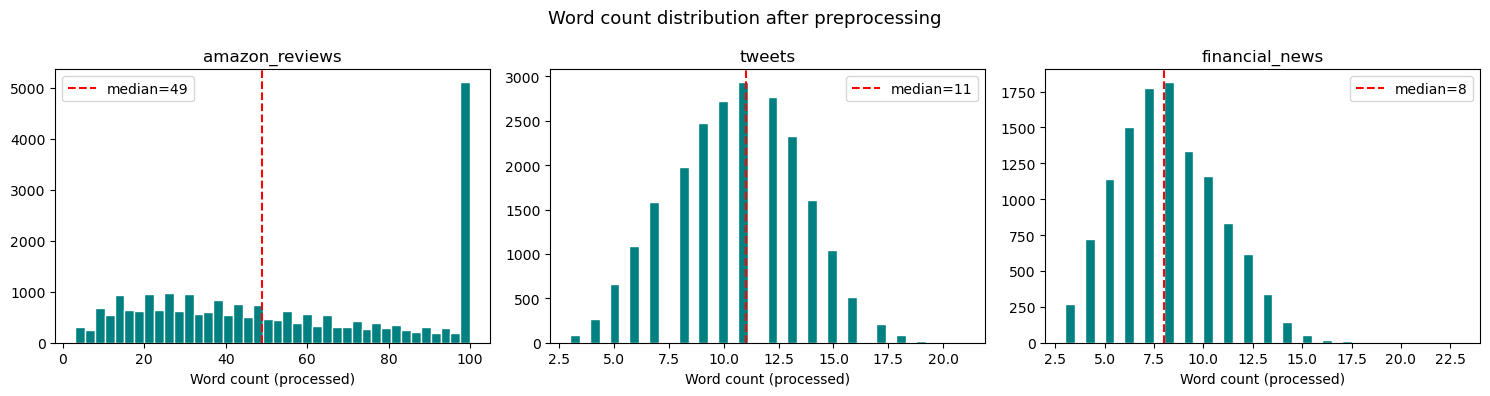

In [3]:
fig, axes = plt.subplots(1, len(DOMAINS), figsize=(15, 4))
for ax, domain in zip(axes, DOMAINS):
    p = Path(f'../data/processed/{domain}_processed.csv')
    if not p.exists():
        ax.set_title(f'{domain}\n(not found)')
        continue
    df = pd.read_csv(p)
    wc = df['text_processed'].str.split().str.len()
    ax.hist(wc.clip(upper=100), bins=40, color='teal', edgecolor='white')
    ax.axvline(wc.median(), color='red', linestyle='--', label=f'median={wc.median():.0f}')
    ax.set_title(domain)
    ax.set_xlabel('Word count (processed)')
    ax.legend()
plt.suptitle('Word count distribution after preprocessing', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Quality checks

In [4]:
for domain in DOMAINS:
    p = Path(f'../data/processed/{domain}_processed.csv')
    if not p.exists():
        print(f'{domain}: NOT FOUND'); continue
    df = pd.read_csv(p)
    wc = df['text_processed'].str.split().str.len()
    print(f'{domain}: rows={len(df):,}  nulls={df["text_processed"].isnull().sum()}  '
          f'too_short={( wc < 3).sum()}  too_long={(wc > 512).sum()}')

amazon_reviews: rows=24,937  nulls=0  too_short=0  too_long=0
tweets: rows=22,390  nulls=0  too_short=0  too_long=0
financial_news: rows=11,767  nulls=0  too_short=0  too_long=0
